# Violence Detection CNN
Binary video classification using a pretrained ResNet-18 backbone with temporal average pooling.

Loads preprocessed data from `preprocessed_data/` (generated by `video_preprocessing.ipynb`).

In [12]:
import os
import random
from collections import deque
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path

%matplotlib inline

In [13]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Training hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE     = 32
EPOCHS         = 50
LEARNING_RATE  = 1e-4
EARLY_STOP_PAT = 10   # epochs without val-acc improvement before stopping
SEQUENCE_LENGTH = 16  # must match preprocessing
IMAGE_HEIGHT    = 64
IMAGE_WIDTH     = 64

# ── Paths ─────────────────────────────────────────────────────────────────────
CLASSES    = ['NonViolence', 'Violence']
DATA_DIR   = Path('preprocessed_data')
MODEL_PATH = 'best_violence_cnn.pth'

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device : {DEVICE}')
print(f'Classes: {CLASSES}')

Device : mps
Classes: ['NonViolence', 'Violence']


In [14]:
# Load preprocessed splits (float32, range [0, 1], shape (N, T, H, W, C))
X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_val   = np.load(DATA_DIR / 'X_val.npy')
y_val   = np.load(DATA_DIR / 'y_val.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

# Per-channel stats computed on the training set during preprocessing
channel_mean = np.load(DATA_DIR / 'channel_mean.npy').tolist()
channel_std  = np.load(DATA_DIR / 'channel_std.npy').tolist()

print(f'Train : {X_train.shape}   labels: {np.bincount(y_train)}')
print(f'Val   : {X_val.shape}   labels: {np.bincount(y_val)}')
print(f'Test  : {X_test.shape}   labels: {np.bincount(y_test)}')
print(f'Channel mean : {[round(v, 4) for v in channel_mean]}')
print(f'Channel std  : {[round(v, 4) for v in channel_std]}')

Train : (2799, 16, 64, 64, 3)   labels: [1399 1400]
Val   : (600, 16, 64, 64, 3)   labels: [300 300]
Test  : (601, 16, 64, 64, 3)   labels: [301 300]
Channel mean : [0.0915, 0.0915, 0.0915]
Channel std  : [0.3024, 0.2998, 0.2992]


In [15]:
# Normalise with stats computed from the training set
_normalize = transforms.Normalize(mean=channel_mean, std=channel_std)


class ViolenceDataset(Dataset):
    """
    Each sample is a clip of shape (T, H, W, C), stored as float32 in [0, 1].
    Augmentation (offline flips, jitter, rotation) was applied during
    preprocessing, so only a lightweight online horizontal flip is used here.
    """

    def __init__(self, features: np.ndarray, labels: np.ndarray, augment: bool = False):
        self.features = features
        self.labels   = labels
        self.augment  = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        frames = torch.from_numpy(self.features[idx]).permute(0, 3, 1, 2)  # (T, 3, H, W)
        label  = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.augment and random.random() < 0.5:
            frames = frames.flip(-1)  # consistent horizontal flip across all frames

        frames = torch.stack([_normalize(f) for f in frames])  # (T, 3, H, W)
        return frames, label


train_dataset = ViolenceDataset(X_train, y_train, augment=True)
val_dataset   = ViolenceDataset(X_val,   y_val,   augment=False)
test_dataset  = ViolenceDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 88
Val   batches : 19
Test  batches : 19


In [16]:
class ViolenceCNN(nn.Module):
    """
    ResNet-18 backbone with temporal average pooling.
    Each frame is encoded independently; embeddings are averaged before
    the classification head.
    """

    def __init__(self, num_classes: int = 2, freeze_until: int = -10):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Drop the final fully-connected layer; output → (B, 512, 1, 1)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])

        # Freeze early layers to preserve pretrained low-level features
        for p in list(self.feature_extractor.parameters())[:freeze_until]:
            p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C, H, W = x.shape
        x        = x.view(B * T, C, H, W)
        features = self.feature_extractor(x).view(B, T, -1)  # (B, T, 512)
        features = features.mean(dim=1)                       # (B, 512)
        return self.classifier(features)


model = ViolenceCNN(num_classes=len(CLASSES)).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Trainable params: 4,985,090 / 11,308,354


In [17]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for frames, labels in tqdm(loader, desc='train', leave=False):
        frames, labels = frames.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(frames)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for frames, labels in tqdm(loader, desc='eval ', leave=False):
            frames, labels = frames.to(DEVICE), labels.to(DEVICE)
            out         = model(frames)
            total_loss += criterion(out, labels).item()
            correct    += (out.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
no_improve   = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model,  val_loader,   criterion)
    scheduler.step(val_acc)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_PAT:
            print(f'Early stopping triggered at epoch {epoch}.')
            break

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

train:   0%|          | 0/88 [00:00<?, ?it/s]

eval :   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01/50  train_loss=0.5296  train_acc=0.7245  val_loss=0.3397  val_acc=0.8567


train:   0%|          | 0/88 [00:00<?, ?it/s]

eval :   0%|          | 0/19 [00:00<?, ?it/s]

...

eval :   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 23/50  train_loss=0.0060  train_acc=0.9982  val_loss=0.0884  val_acc=0.9750


train:   0%|          | 0/88 [00:00<?, ?it/s]

eval :   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 24/50  train_loss=0.0092  train_acc=0.9964  val_loss=0.1040  val_acc=0.9767
Early stopping triggered at epoch 24.

Best validation accuracy: 0.9817


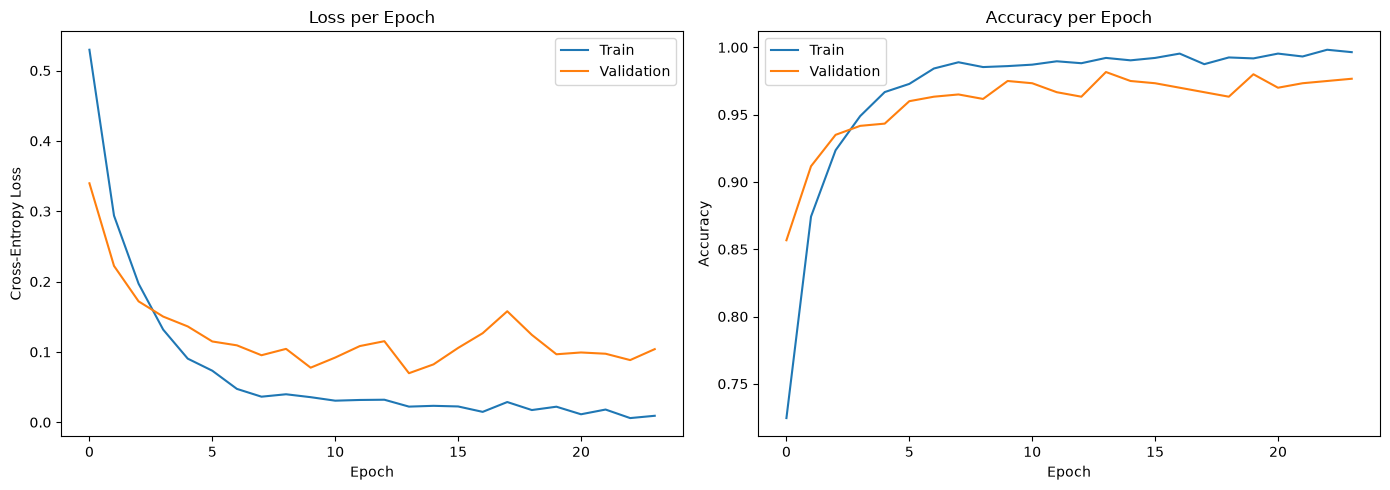

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Validation')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Validation')
ax2.set_title('Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

              precision    recall  f1-score   support

 NonViolence       0.98      1.00      0.99       301
    Violence       1.00      0.98      0.99       300

    accuracy                           0.99       601
   macro avg       0.99      0.99      0.99       601
weighted avg       0.99      0.99      0.99       601



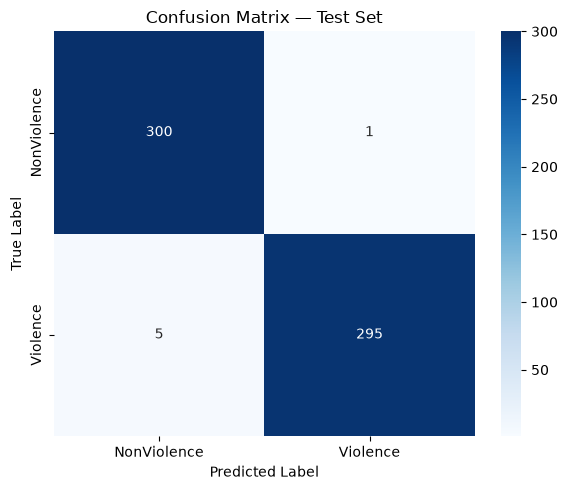

In [20]:
# Evaluate the best checkpoint on the held-out test set
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for frames, labels in test_loader:
        preds = model(frames.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [21]:
torch.save({
    'model_state_dict': model.state_dict(),
    'classes':          CLASSES,
    'channel_mean':     channel_mean,
    'channel_std':      channel_std,
    'best_val_acc':     best_val_acc,
}, 'violence_cnn_final.pth')

print('Model saved to violence_cnn_final.pth')

Model saved to violence_cnn_final.pth


---
## Real-Time Inference
Two inference modes adapted from the MobileNet-BiLSTM reference notebook:
- **`predict_video`** — uniform frame sampling, single forward pass, returns class + confidence
- **`predict_frames`** — sliding window over every frame, writes an annotated output video

In [22]:
def predict_video(video_path: str, sequence_length: int = SEQUENCE_LENGTH) -> tuple:
    """
    Uniformly sample `sequence_length` frames from a video, run a single
    forward pass, and print the predicted class with confidence.
    """
    cap          = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    skip         = max(total_frames // sequence_length, 1)

    frames = []
    for i in range(sequence_length):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * skip)
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
                           (IMAGE_WIDTH, IMAGE_HEIGHT))
        frames.append(frame.astype(np.float32) / 255.0)
    cap.release()

    clip = torch.from_numpy(np.stack(frames)).permute(0, 3, 1, 2)   # (T, 3, H, W)
    clip = torch.stack([_normalize(f) for f in clip]).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(clip), dim=1)[0].cpu()

    idx        = probs.argmax().item()
    class_name = CLASSES[idx]
    confidence = probs[idx].item()

    print(f'Predicted     : {class_name}')
    print(f'Confidence    : {confidence:.4f}  ({confidence * 100:.2f}%)')
    print(f'Probabilities : { {c: round(p, 4) for c, p in zip(CLASSES, probs.tolist())} }')
    return class_name, confidence

In [23]:
def predict_frames(
    video_path: str,
    output_path: str,
    sequence_length: int = SEQUENCE_LENGTH
) -> None:
    """
    Slide a rolling window of `sequence_length` frames through a video.
    A prediction is made on every new frame once the queue is full.
    Writes an annotated output video with the predicted label overlaid.
    """
    cap    = cv2.VideoCapture(video_path)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS) or 25.0

    os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height)
    )

    frames_queue    = deque(maxlen=sequence_length)
    predicted_label = ''
    confidence      = 0.0

    model.eval()
    while cap.isOpened():
        ok, frame = cap.read()
        if not ok:
            break

        # Preprocess: resize to model input size, normalise to [0, 1]
        small = cv2.resize(
            cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
            (IMAGE_WIDTH, IMAGE_HEIGHT)
        ).astype(np.float32) / 255.0
        frames_queue.append(small)

        if len(frames_queue) == sequence_length:
            clip = torch.from_numpy(np.stack(frames_queue)).permute(0, 3, 1, 2)
            clip = torch.stack([_normalize(f) for f in clip]).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                probs = torch.softmax(model(clip), dim=1)[0].cpu()
            idx             = probs.argmax().item()
            predicted_label = CLASSES[idx]
            confidence      = probs[idx].item()

        # Overlay prediction on the original full-resolution frame
        if predicted_label:
            colour = (0, 0, 255) if predicted_label == 'Violence' else (0, 200, 0)
            text   = f'{predicted_label}  {confidence * 100:.1f}%'
            cv2.putText(frame, text, (10, 60),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.8, colour, 4)

        writer.write(frame)

    cap.release()
    writer.release()
    print(f'Annotated video saved → {output_path}')

In [24]:
# ── Pick sample videos from the cached dataset ────────────────────────────────
import kagglehub

kaggle_path = kagglehub.dataset_download('mohamedmustafa/real-life-violence-situations-dataset')
DATASET_DIR = Path(kaggle_path) / 'real life violence situations' / 'Real Life Violence Dataset'

sample_violence    = random.choice(list((DATASET_DIR / 'Violence').glob('*.mp4')))
sample_nonviolence = random.choice(list((DATASET_DIR / 'NonViolence').glob('*.mp4')))

# ── Whole-video prediction ────────────────────────────────────────────────────
print('── Violence sample ──')
predict_video(str(sample_violence))

print('\n── NonViolence sample ──')
predict_video(str(sample_nonviolence))

── Violence sample ──
Predicted     : Violence
Confidence    : 0.9996  (99.96%)
Probabilities : {'NonViolence': 0.0004, 'Violence': 0.9996}

── NonViolence sample ──
Predicted     : NonViolence
Confidence    : 1.0000  (100.00%)
Probabilities : {'NonViolence': 1.0, 'Violence': 0.0}


('NonViolence', 0.9999998807907104)

In [25]:
# ── Sliding-window annotated videos ──────────────────────────────────────────
predict_frames(str(sample_violence),    'output_videos/violence_annotated.mp4')
predict_frames(str(sample_nonviolence), 'output_videos/nonviolence_annotated.mp4')

Annotated video saved → output_videos/violence_annotated.mp4
Annotated video saved → output_videos/nonviolence_annotated.mp4
